# Load data

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_DBR
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode, LL_RT

In [30]:
nameFile = 'Cleaned_data_Open_loop_experiment_on_MV_2026-03-03-13h34.txt'

titleName = nameFile.split('.')[0]    
data = pd.read_csv('Data/' + nameFile)

if 'MV' in nameFile:
    ExpVariable = 'MV'
    tm = data['tm'].values
    MVm = data['MVm'].values
    PVm = data['PVm'].values    
else:    
    ExpVariable = 'DV'
    tm = data['tm'].values
    DVm = data['DVm'].values 
    PVm = data['PVm'].values
     
print(ExpVariable)    

MV


# Parameters optimal FOPDT & SOPDT models

In [31]:
Kp_FOPDTOPT =  0.3437198259244558
T_FOPDTOPT =  193.65264048073982
theta_FOPDTOPT = 36.299353715107564

Kp_SOPDTOPT = 0.34256429499445384
T1_SOPDTOPT = 187.62310729883146
T2_SOPDTOPT = 27.696651047299913
theta_SOPDTOPT = 11.137352121206844   

Tu = 38 
Tg = 214
t1 = 105
t2 = 128
a =0.1
Kp = 0.33
print(Tu/Tg)

T1_Grin = Tg * (((3*a*np.e)-1)/(1+(a*np.e)))
T2_Grin = Tg * ((1-(a*np.e))/(1+(a*np.e)))
theta_Grin = Tu - ((T1_Grin*T2_Grin)/(T1_Grin + (3 * T2_Grin)))
T_str = Tg / 2.72
theta_str = Tu - (0.10*Tg)
T_com = 5.5*(t2-t1)
theta_com = (2.8*t1) - (1.8*t2)
print(T1_Grin, T2_Grin, theta_str, theta_com )
Ts = 1


0.17757009345794392
-31.046887579242654 122.52344378962133 16.599999999999998 63.599999999999994


# Compare step responses (experiment compared with optimal FOPDT & SOPDT)

(0.0, 861.0)

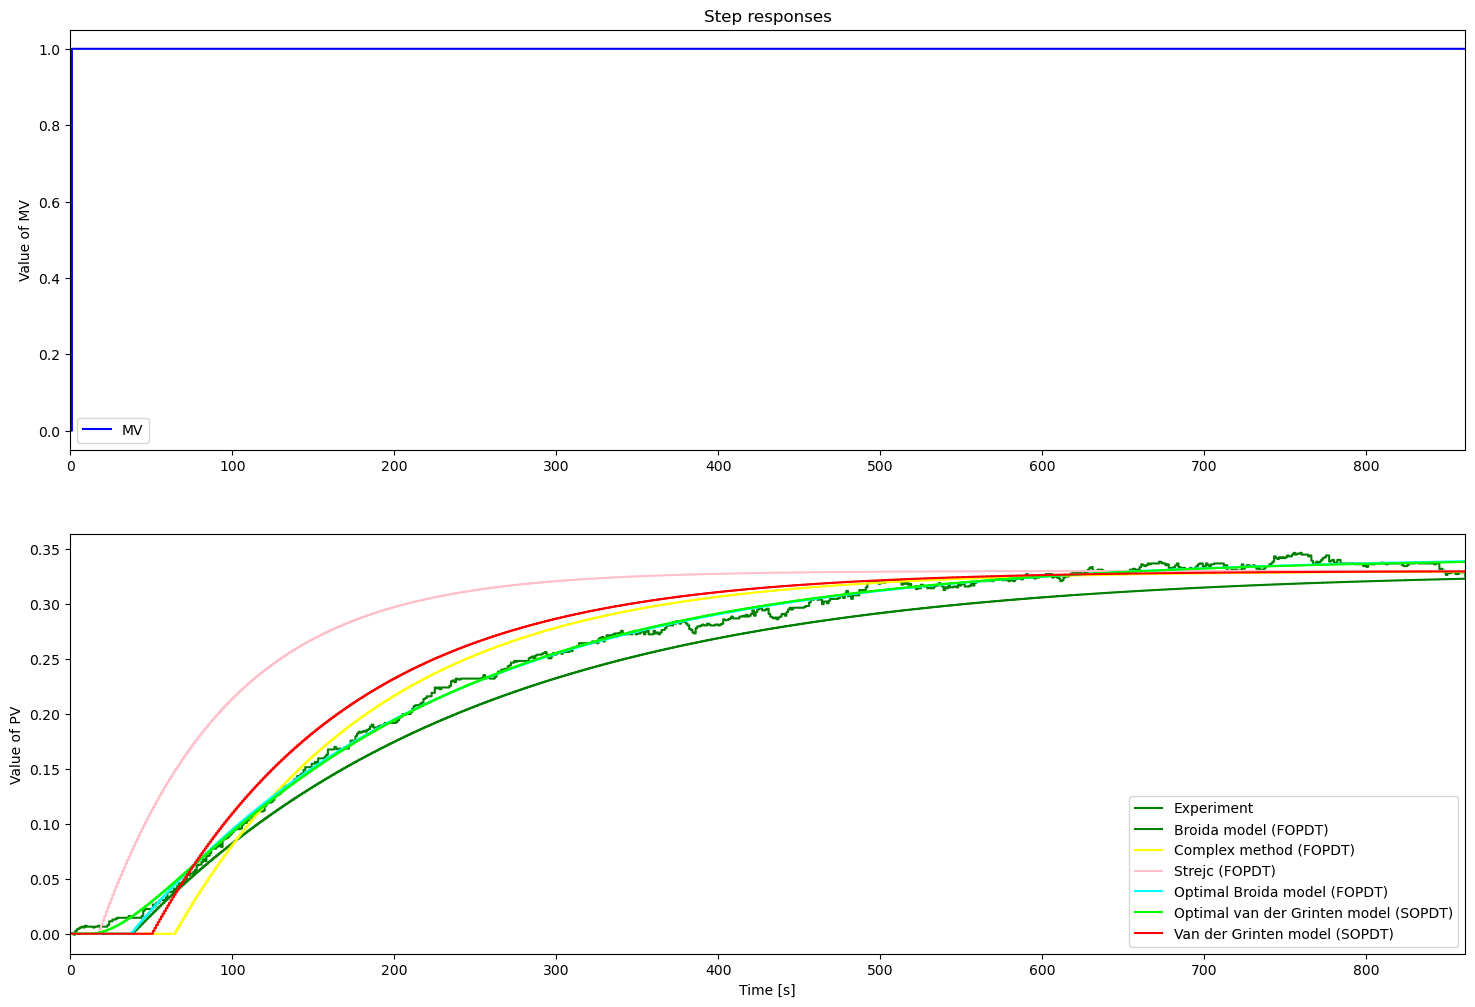

In [32]:
PV_SOPDTOPT_cost = SOPDT(MVm,Kp_SOPDTOPT,T1_SOPDTOPT,T2_SOPDTOPT,theta_SOPDTOPT,Ts)
PV_FOPDTOPT_cost = FOPDT(MVm,Kp_FOPDTOPT,T_FOPDTOPT,theta_FOPDTOPT,Ts)
PV_FOPDTOPT_Bro = FOPDT(MVm,Kp,Tg,Tu,Ts)
PV_FOPDTOPT_com = FOPDT(MVm,Kp,T_com,theta_com,Ts)
PV_SOPDTOPT_Grin = SOPDT(MVm,Kp,0,T2_Grin,theta_Grin,Ts)
PV_FOPDTOPT_str = FOPDT(MVm,Kp,T_str,theta_str,Ts)


plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
plt.step(tm,MVm,'b-',label='MV',where='post')
plt.ylabel('Value of MV')
plt.title('Step responses')
plt.legend(loc='best')
plt.xlim([0, np.max(tm)])   

plt.subplot(2,1,2)
plt.step(tm,PVm,'g-',label='Experiment',where='post')
plt.step(tm,PV_FOPDTOPT_Bro,'g',label='Broida model (FOPDT)',where='post')
plt.step(tm,PV_FOPDTOPT_com,'yellow',label='Complex method (FOPDT)',where='post')
plt.step(tm,PV_FOPDTOPT_str,'pink',label='Strejc (FOPDT)',where='post')

plt.step(tm,PV_FOPDTOPT_cost,'cyan',label='Optimal Broida model (FOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT_cost,'lime',label='Optimal van der Grinten model (SOPDT)',where='post')
plt.step(tm,PV_SOPDTOPT_Grin,'r',label='Van der Grinten model (SOPDT)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')  
plt.xlim([0, np.max(tm)])

# Compare Bode diagrams (optimal FOPDT & SOPDT)

Text(0, 0.5, 'Phase [°]')

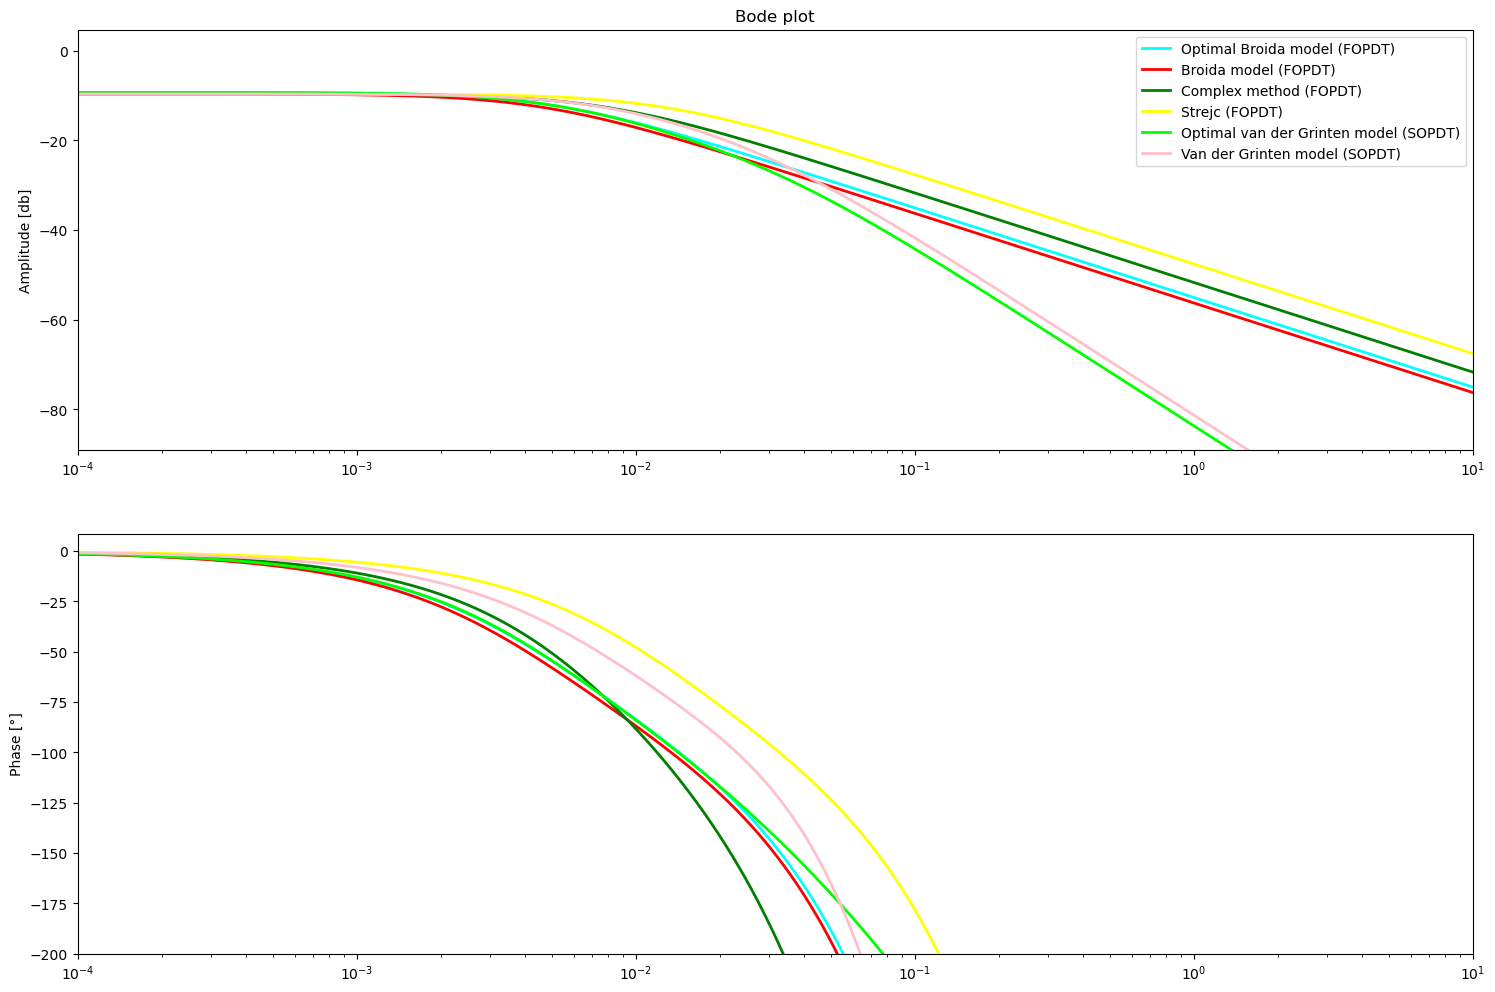

In [33]:
# Frequency response Optimal/cost FOPDT
P_FOPDTOPT = Process({})
P_FOPDTOPT.parameters['Kp'] = Kp_FOPDTOPT
P_FOPDTOPT.parameters['Tlag1'] = T_FOPDTOPT
P_FOPDTOPT.parameters['theta'] = theta_FOPDTOPT

P_FOPDTOPT_Bro = Process({})
P_FOPDTOPT_Bro.parameters['Kp'] = Kp
P_FOPDTOPT_Bro.parameters['Tlag1'] = Tg
P_FOPDTOPT_Bro.parameters['theta'] = Tu

P_FOPDTOPT_com = Process({})
P_FOPDTOPT_com.parameters['Kp'] = Kp
P_FOPDTOPT_com.parameters['Tlag1'] = T_com
P_FOPDTOPT_com.parameters['theta'] = theta_com

P_FOPDTOPT_str = Process({})
P_FOPDTOPT_str.parameters['Kp'] = Kp
P_FOPDTOPT_str.parameters['Tlag1'] = T_str
P_FOPDTOPT_str.parameters['theta'] = theta_str

# Frequency response Optimal/cost SOPDT
P_SOPDTOPT = Process({})
P_SOPDTOPT.parameters['Kp'] = Kp_SOPDTOPT
P_SOPDTOPT.parameters['Tlag1'] = T1_SOPDTOPT
P_SOPDTOPT.parameters['Tlag2'] = T2_SOPDTOPT
P_SOPDTOPT.parameters['theta'] = theta_SOPDTOPT

P_SOPDTOPT_GRIN = Process({})
P_SOPDTOPT_GRIN.parameters['Kp'] = Kp
P_SOPDTOPT_GRIN.parameters['Tlag1'] = T1_Grin
P_SOPDTOPT_GRIN.parameters['Tlag2'] = T2_Grin
P_SOPDTOPT_GRIN.parameters['theta'] = theta_Grin

omega = np.logspace(-4, 1, 10000)
Ps_FOPDTOPT = Bode(P_FOPDTOPT,omega,False) # Optimal Broida
Ps_FOPDTOPT_Bro = Bode(P_FOPDTOPT_Bro,omega,False)
Ps_FOPDTOPT_com = Bode(P_FOPDTOPT_com,omega,False)
Ps_FOPDTOPT_str = Bode(P_FOPDTOPT_str,omega,False)
Ps_SOPDTOPT = Bode(P_SOPDTOPT,omega,False) # Optimal van der Grinten
Ps_SOPDTOPT_GRIN = Bode(P_SOPDTOPT_GRIN,omega,False)


plt.figure(figsize = (18,12))

plt.subplot(2,1,1)
gain_min = np.min(20*np.log10(np.abs(Ps_FOPDTOPT)/5))
gain_max = np.max(20*np.log10(np.abs(Ps_FOPDTOPT)*5))
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT)),'cyan',linewidth=2,label='Optimal Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_Bro)),'r',linewidth=2,label='Broida model (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_com)),'g',linewidth=2,label='Complex method (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_FOPDTOPT_str)),'yellow',linewidth=2,label='Strejc (FOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT)),'lime',linewidth=2,label='Optimal van der Grinten model (SOPDT)')
plt.semilogx(omega,20*np.log10(np.abs(Ps_SOPDTOPT_GRIN)),'pink',linewidth=2,label='Van der Grinten model (SOPDT)')
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([gain_min, gain_max])
plt.ylabel('Amplitude [db]')
plt.title('Bode plot')
plt.legend(loc='best')

plt.subplot(2,1,2)
ph_min = np.min((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) - 10
ph_max = np.max((180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT))) + 10
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT)),'cyan',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_Bro)),'r',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_com)),'g',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_FOPDTOPT_str)),'yellow',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT)),'lime',linewidth=2)
plt.semilogx(omega, (180/np.pi)*np.unwrap(np.angle(Ps_SOPDTOPT_GRIN)),'pink',linewidth=2)
plt.xlim([np.min(omega), np.max(omega)])
plt.ylim([np.max([ph_min, -200]), ph_max])
plt.ylabel('Phase [°]')

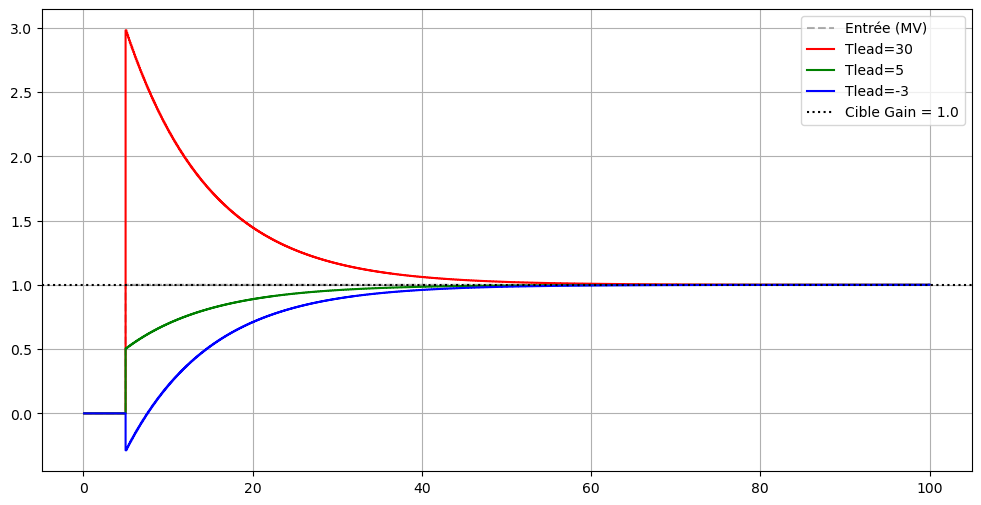

In [34]:
import numpy as np
import matplotlib.pyplot as plt


TSim = 100
Ts = 0.1 
N = int(TSim/Ts) + 1
t = []
MV = [] 
PV_lead = []; PV_lead2 = []; PV_lead3 = [] 

MVPath = {0: 0, 5: 1, TSim: 1}
Tlag_fixe = 10.0
Kp = 1.0


for i in range(1, N):
    t.append(i * Ts)
    SelectPath_RT(MVPath, t, MV)
    
    LL_RT(MV, Kp, 30.0, Tlag_fixe, Ts, PV_lead, method='EBD')
    LL_RT(MV, Kp, 5.0,  Tlag_fixe, Ts, PV_lead2, method='EBD')
    LL_RT(MV, Kp, -3.0, Tlag_fixe, Ts, PV_lead3, method='EBD')

plt.figure(figsize=(12, 6))
plt.step(t, MV, 'k--', label='Entrée (MV)', where='post', alpha=0.3)
plt.step(t, PV_lead, 'r-', label='Tlead=30 ', where='post')
plt.step(t, PV_lead2, 'g-', label='Tlead=5 ', where='post')
plt.step(t, PV_lead3, 'b-', label='Tlead=-3 ', where='post')
plt.axhline(y=Kp, color='k', linestyle=':', label='Cible Gain = 1.0')
plt.legend(); plt.grid(True); plt.show()

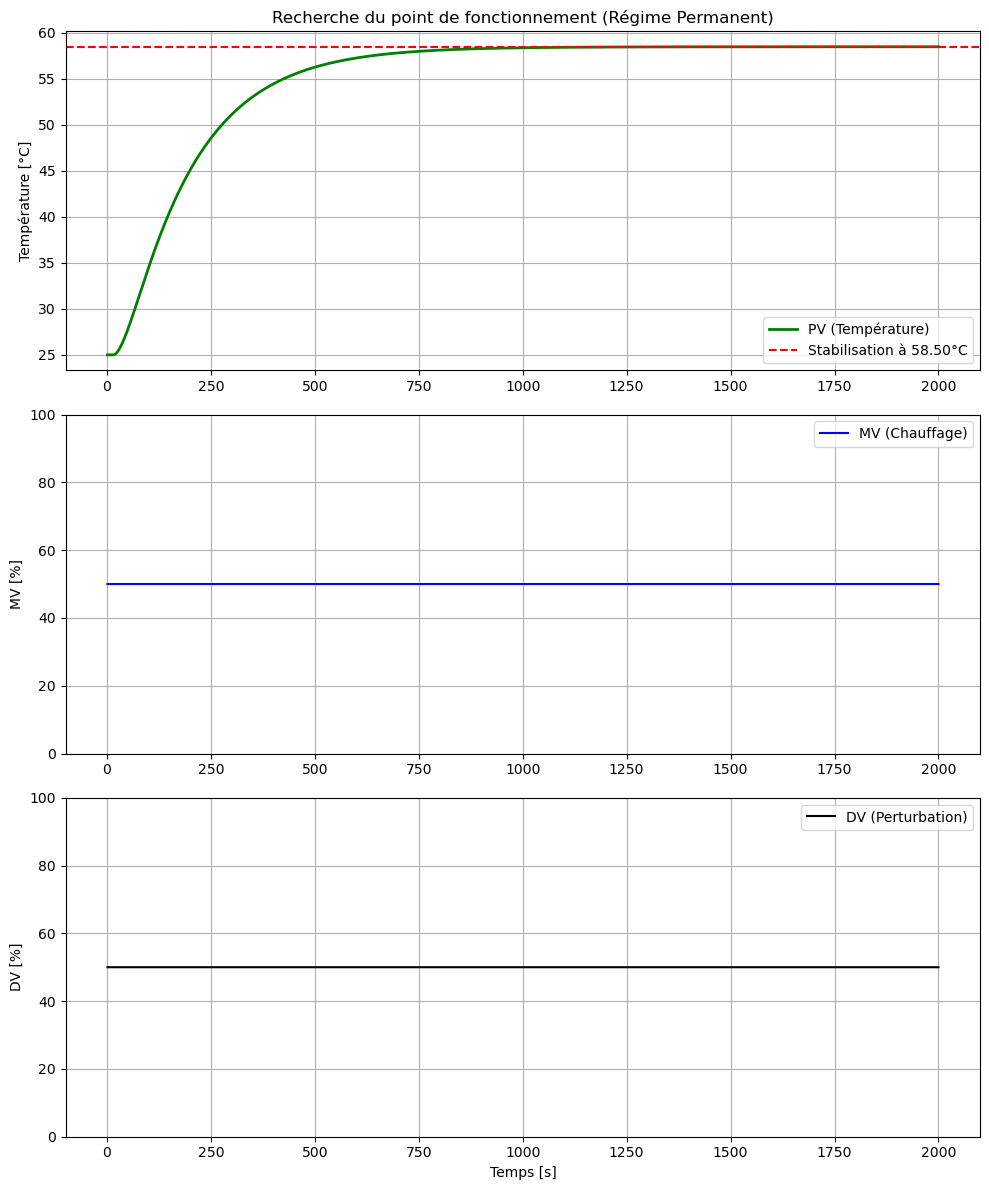

La température PV tend vers : 58.50 °C


In [35]:
TSim = 2000 
Ts = 1 
N = int(TSim/Ts) + 1

Kp, Tp1, Tp2, thetap = 0.36, 170.82, 26.55, 13.31
Kd, Td1, Td2, thetad = 0.31, 161.20, 32.3, 15.75
Tamb = 20.0 

t = []
MV = []
DV = []
PV = [] 

MV_delayed = []
PV1p = []
PV2p = [] 

DV_delayed = []
PV1d = []
PV2d = []

MVPath = {0: 50, TSim: 50}
DVPath = {0: 50, TSim: 50}

for i in range(1, N):
    t.append(i * Ts)
    
    SelectPath_RT(MVPath, t, MV)
    SelectPath_RT(DVPath, t, DV)
    
    Delay_RT(MV, thetap, Ts, MV_delayed)
    FO_RT(MV_delayed, Kp, Tp1, Ts, PV1p)
    FO_RT(PV1p, 1.0, Tp2, Ts, PV2p)
    
    Delay_RT(DV, thetad, Ts, DV_delayed)
    FO_RT(DV_delayed, Kd, Td1, Ts, PV1d)
    FO_RT(PV1d, 1.0, Td2, Ts, PV2d)
    
    PV.append(PV2p[-1] + PV2d[-1] + Tamb)

plt.figure(figsize=(10, 12))

plt.subplot(3, 1, 1)
plt.plot(t, PV, 'g-', lw=2, label='PV (Température)')
plt.axhline(y=PV[-1], color='r', linestyle='--', label=f'Stabilisation à {PV[-1]:.2f}°C')
plt.ylabel('Température [°C]')
plt.title('Recherche du point de fonctionnement (Régime Permanent)')
plt.legend() 
plt.grid(True)

plt.subplot(3, 1, 2)
plt.step(t, MV, 'b-', label='MV (Chauffage)')
plt.ylim(0, 100) 
plt.ylabel('MV [%]')
plt.legend() 
plt.grid(True)

plt.subplot(3, 1, 3)
plt.step(t, DV, 'k-', label='DV (Perturbation)')
plt.ylim(0, 100) 
plt.ylabel('DV [%]')
plt.xlabel('Temps [s]')
plt.legend() 
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"La température PV tend vers : {PV[-1]:.2f} °C")